#Projet d’Optimisation Convexe



##Étape 1 : Formulation du problème & Visualisation



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.patches import Patch
import matplotlib.tri as mtri
import itertools

In [2]:
# Objective function
def objective(x, y, z):
    return x**2 + y**2 + z**2

# Constraint functions (inequality form: g(x) <= 0)
def g1(x, y, z):
    return x + y + z - 5

def g2(x, y, z):
    return x - y - 1

def g3(x):
    return -x

def g4(y):
    return -y

def g5(z):
    return -z

In [3]:
# Generate a grid of points in 3D space
num_points = 100000
np.random.seed(0)
X = np.random.uniform(0, 5, num_points)
Y = np.random.uniform(0, 5, num_points)
Z = np.random.uniform(0, 5, num_points)

# Apply constraints (only keep feasible points)
feasible_idx = np.where(
    (g1(X, Y, Z) <= 0) &
    (g2(X, Y, Z) <= 0) &
    (g3(X) <= 0) &
    (g4(Y) <= 0) &
    (g5(Z) <= 0)
)

X_feas = X[feasible_idx]
Y_feas = Y[feasible_idx]
Z_feas = Z[feasible_idx]

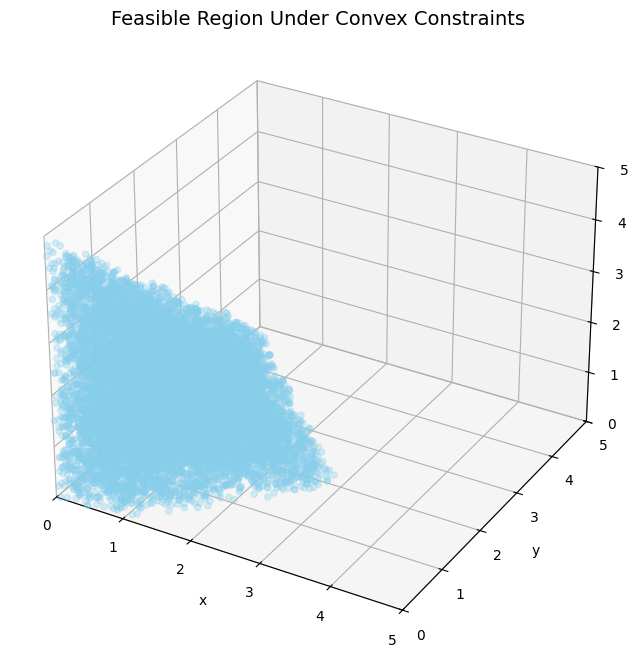

In [4]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_title("Feasible Region Under Convex Constraints", fontsize=14)

# Scatter plot of feasible points
ax.scatter(X_feas, Y_feas, Z_feas, c='skyblue', marker='o', alpha=0.3)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

# Axes limits
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
ax.set_zlim(0, 5)

plt.show()

##Étape 2 : Conditions de Karush-Kuhn-Tucker (KKT)


In [5]:
import sympy as sp

# Define variables
x, y, z = sp.symbols('x y z', real=True)
l1, l2, l3, l4, l5 = sp.symbols('l1 l2 l3 l4 l5', real=True)

# Objective function
f = x**2 + y**2 + z**2

# Constraints in g(x) ≤ 0 form
g1 = x + y + z - 5     # x + y + z ≤ 5 → g1 ≤ 0
g2 = x - y - 1         # x - y ≤ 1 → g2 ≤ 0
g3 = -x                # x ≥ 0 → g3 ≤ 0
g4 = -y                # y ≥ 0 → g4 ≤ 0
g5 = -z                # z ≥ 0 → g5 ≤ 0

In [6]:
# Lagrangian (L)
L = f + l1 * g1 + l2 * g2 + l3 * g3 + l4 * g4 + l5 * g5

In [7]:
# Compute partial derivatives (∇L == 0)
grad_L_x = sp.diff(L, x)
grad_L_y = sp.diff(L, y)
grad_L_z = sp.diff(L, z)

stationarity = [
    sp.Eq(grad_L_x, 0),
    sp.Eq(grad_L_y, 0),
    sp.Eq(grad_L_z, 0)
]
stationarity

[Eq(l1 + l2 - l3 + 2*x, 0), Eq(l1 - l2 - l4 + 2*y, 0), Eq(l1 - l5 + 2*z, 0)]

In [8]:
# Complementary slackness: λ_i * g_i(x) == 0
complementarity = [
    sp.Eq(l1 * g1, 0),
    sp.Eq(l2 * g2, 0),
    sp.Eq(l3 * g3, 0),
    sp.Eq(l4 * g4, 0),
    sp.Eq(l5 * g5, 0)
]

# Dual feasibility: λ_i ≥ 0
dual_feasibility = [
    sp.Ge(l1, 0),
    sp.Ge(l2, 0),
    sp.Ge(l3, 0),
    sp.Ge(l4, 0),
    sp.Ge(l5, 0)
]

In [9]:
# Primal feasibility: constraints must be satisfied
primal_feasibility = [
    sp.Le(g1, 0),
    sp.Le(g2, 0),
    sp.Le(g3, 0),
    sp.Le(g4, 0),
    sp.Le(g5, 0)
]

In [10]:
print("Stationarity conditions:")
for eq in stationarity:
    sp.pprint(eq)

print("\nComplementary Slackness:")
for eq in complementarity:
    sp.pprint(eq)

print("\nDual Feasibility:")
for ineq in dual_feasibility:
    sp.pprint(ineq)

print("\nPrimal Feasibility:")
for ineq in primal_feasibility:
    sp.pprint(ineq)

Stationarity conditions:
l₁ + l₂ - l₃ + 2⋅x = 0
l₁ - l₂ - l₄ + 2⋅y = 0
l₁ - l₅ + 2⋅z = 0

Complementary Slackness:
l₁⋅(x + y + z - 5) = 0
l₂⋅(x - y - 1) = 0
-l₃⋅x = 0
-l₄⋅y = 0
-l₅⋅z = 0

Dual Feasibility:
l₁ ≥ 0
l₂ ≥ 0
l₃ ≥ 0
l₄ ≥ 0
l₅ ≥ 0

Primal Feasibility:
x + y + z - 5 ≤ 0
x - y - 1 ≤ 0
-x ≤ 0
-y ≤ 0
-z ≤ 0


##Étape 3 : Implémentation numérique — Méthode du Gradient Projeté.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp

In [14]:
def project_to_feasible(x_input):
    x_var = cp.Variable(3)
    constraints = [
        x_var[0] + x_var[1] + x_var[2] <= 5,
        x_var[0] - x_var[1] <= 1,
        x_var[0] >= 0,
        x_var[1] >= 0,
        x_var[2] >= 0
    ]
    objective = cp.Minimize(cp.sum_squares(x_var - x_input))
    prob = cp.Problem(objective, constraints)
    prob.solve()
    return x_var.value

In [15]:
def projected_gradient_descent(
    initial_point=np.array([1.0, 1.0, 1.0]),
    step_size=0.1,
    max_iter=100,
    tol=1e-6
):
    x_k = initial_point.copy()
    history = [x_k.copy()]

    for k in range(max_iter):
        grad = 2 * x_k  # ∇f = [2x, 2y, 2z]
        x_next = x_k - step_size * grad
        x_next_projected = project_to_feasible(x_next)

        # Check convergence
        if np.linalg.norm(x_k - x_next_projected) < tol:
            break

        x_k = x_next_projected
        history.append(x_k.copy())

    return np.array(history), x_k

Optimal point (approx): [2.39452428e-06 2.39452428e-06 2.39452428e-06]
Optimal value: 0.0000


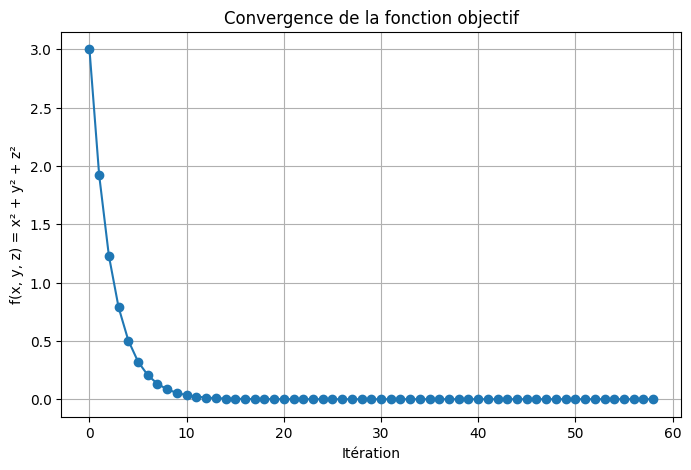

In [16]:
trajectory, solution = projected_gradient_descent()

print(f"Optimal point (approx): {solution}")
print(f"Optimal value: {np.sum(solution**2):.4f}")

# Plot convergence of objective value
objective_values = [np.sum(x**2) for x in trajectory]

plt.figure(figsize=(8,5))
plt.plot(objective_values, marker='o')
plt.title('Convergence de la fonction objectif')
plt.xlabel('Itération')
plt.ylabel('f(x, y, z) = x² + y² + z²')
plt.grid(True)
plt.show()

In [17]:
# Define and solve the problem using CVXPY (direct convex optimization)
x_var = cp.Variable(3)

objective = cp.Minimize(cp.sum_squares(x_var))  # x² + y² + z²
constraints = [
    x_var[0] + x_var[1] + x_var[2] <= 5,
    x_var[0] - x_var[1] <= 1,
    x_var[0] >= 0,
    x_var[1] >= 0,
    x_var[2] >= 0
]

problem = cp.Problem(objective, constraints)
problem.solve()

print("✅ CVXPY Solution:")
print(f"x* = {x_var.value}")
print(f"Objective value: {problem.value:.4f}")

Polishing not needed - no active set detected at optimal point
✅ CVXPY Solution:
x* = [0. 0. 0.]
Objective value: 0.0000
